# Phase 4 - Opening Match: Model vs. Market / Phase 4 - Eröffnungsspiel: Modell vs. Markt

A live, timestamped showdown for the 2026 World Cup opener (Mexico vs. South Africa,
11 June 2026, kickoff 21:00 Berlin). We pit the Elo model's prediction against the
median implied probability across 23 bookmakers, save both, then wait for the
result to see who was better calibrated.

This is one match, not statistical evidence about the model. But it's a clean
template: the same flow will be applied to every subsequent match as the
tournament unfolds.

---

Ein live, zeitgestempelter Vergleich für das Eröffnungsspiel der WM 2026 (Mexiko
gegen Südafrika, 11. Juni 2026, Anpfiff 21:00 Berlin). Wir setzen die Vorhersage
des Elo-Modells gegen die mediane implizite Wahrscheinlichkeit von 23 Buchmachern,
speichern beide und warten auf das Ergebnis, um zu sehen, wer besser kalibriert war.

Dies ist ein Spiel, kein statistischer Beweis über das Modell. Aber es ist eine
saubere Vorlage: derselbe Ablauf wird auf jedes weitere Spiel im Turnierverlauf angewendet.

## 1. Load model and live odds / Modell und Live-Quoten laden

Bring in the Elo ratings from Phase 1 and the live odds log that the GitHub
Actions workflow has been collecting hourly since the tournament started. A
quick check of the matches in the log confirms we have the full picture.

---

Laden der Elo-Bewertungen aus Phase 1 und des Live-Quoten-Logs, den der GitHub
Actions Workflow seit Turnierbeginn stündlich sammelt. Eine schnelle Prüfung
der Spiele im Log bestätigt, dass wir den vollständigen Überblick haben.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import sys
sys.path.insert(0, '..')

# Reload modules and data
from src.groups import GROUPS

with open("../data/processed/elo_ratings.json") as f:
    elo = json.load(f)

# Load the live odds log we've been collecting
odds = pd.read_csv("../data/odds_log.csv.gz", parse_dates=["captured_at", "commence_time"])
print(f"Total odds rows collected: {len(odds):,}")
print(f"Snapshot count (unique captured_at): {odds['captured_at'].nunique()}")
print(f"Bookmakers represented: {odds['bookmaker'].nunique()}")
print(f"\nMatches in the log:")
print(odds.groupby(['home', 'away'])['captured_at'].nunique().sort_values(ascending=False).head(15))

Total odds rows collected: 42,135
Snapshot count (unique captured_at): 10
Bookmakers represented: 25

Matches in the log:
home          away       
Algeria       Austria        10
Argentina     Algeria        10
Saudi Arabia  Uruguay        10
Qatar         Switzerland    10
Portugal      Uzbekistan     10
              DR Congo       10
Paraguay      Australia      10
Panama        England        10
              Croatia        10
Norway        Senegal        10
              France         10
New Zealand   Egypt          10
              Belgium        10
Netherlands   Sweden         10
              Japan          10
Name: captured_at, dtype: int64


## 2. Isolate the opening match / Das Eröffnungsspiel isolieren

Filter to Mexico vs. South Africa, take the most recent snapshot as the
"closing line" approximation, and compute the average decimal odds across all
23 bookmakers covering this match.

---

Filtern auf Mexiko gegen Südafrika, der jüngste Snapshot als Annäherung an die
Schlussquote, und Berechnung der durchschnittlichen Dezimalquoten über alle 23
Buchmacher, die dieses Spiel anbieten.

In [2]:
# Find the opening match (Mexico vs South Africa, June 11)
opener = odds[((odds['home'] == 'Mexico') & (odds['away'] == 'South Africa')) |
              ((odds['home'] == 'South Africa') & (odds['away'] == 'Mexico'))].copy()

print(f"Opening match snapshots: {opener['captured_at'].nunique()}")
print(f"Total odds rows for opener: {len(opener)}")
print(f"Bookmakers covering this match: {opener['bookmaker'].nunique()}")
print(f"Time range: {opener['captured_at'].min()} to {opener['captured_at'].max()}")

# Get the LATEST snapshot (closing line approximation)
latest_ts = opener['captured_at'].max()
latest = opener[opener['captured_at'] == latest_ts].copy()
print(f"\n=== Latest snapshot ({latest_ts}) ===")
print(f"Bookmakers in latest snapshot: {latest['bookmaker'].nunique()}")

# Average decimal odds per outcome (Mexico / South Africa / Draw)
# The 'team' column tells us which side the odds is for
avg_odds = latest.groupby('team')['odds'].agg(['mean', 'min', 'max', 'count'])
print(f"\nAverage decimal odds across bookmakers:")
print(avg_odds.round(3))

Opening match snapshots: 10
Total odds rows for opener: 726
Bookmakers covering this match: 25
Time range: 2026-06-09 21:04:29.896388+00:00 to 2026-06-10 19:00:45.047545+00:00

=== Latest snapshot (2026-06-10 19:00:45.047545+00:00) ===
Bookmakers in latest snapshot: 23

Average decimal odds across bookmakers:
               mean   min    max  count
team                                   
Draw          4.497  4.00   4.80     23
Mexico        1.410  1.37   1.44     23
South Africa  8.830  7.50  10.00     23


## 3. Compare model and market / Modell und Markt vergleichen

Convert bookmaker odds to implied probabilities (adjusting for the bookmaker
margin or "vig"), then compute the Elo model's probability for the same match.
Mexico is the host, so the model applies a +65 home advantage. The edge column
shows where the two disagree most: the model is more bullish on Mexico, the
market on a draw.

---

Umrechnung der Buchmacherquoten in implizite Wahrscheinlichkeiten (bereinigt um
die Buchmachermarge bzw. "Vig"), anschließend Berechnung der Wahrscheinlichkeit
des Elo-Modells für dasselbe Spiel. Mexiko ist Gastgeber, also vergibt das Modell
einen Heimvorteil von +65. Die Edge-Spalte zeigt, wo beide am stärksten abweichen:
das Modell schätzt Mexiko optimistischer ein, der Markt das Unentschieden.

In [3]:
# Convert bookmaker odds to implied probabilities
# Implied prob = 1 / decimal_odds, but the sum exceeds 1 because of the "vig" (bookmaker margin).
# We normalize by dividing each by the total to get a fair probability estimate.

implied_raw = {
    'Mexico':       1 / avg_odds.loc['Mexico', 'mean'],
    'South Africa': 1 / avg_odds.loc['South Africa', 'mean'],
    'Draw':         1 / avg_odds.loc['Draw', 'mean'],
}
total_raw = sum(implied_raw.values())
vig = total_raw - 1
implied_fair = {k: v / total_raw for k, v in implied_raw.items()}

print(f"Bookmaker vig (overround): {vig*100:.2f}%")
print(f"\nImplied probabilities (vig-adjusted, market consensus):")
for outcome, p in implied_fair.items():
    print(f"  {outcome:14s}  {p*100:5.1f}%   (decimal odds {1/implied_raw[outcome]:.3f})")

# --- Now the model's prediction ---
INITIAL_ELO = 1500
HOME_ADVANTAGE = 65

def expected_score(rating_a, rating_b):
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))

# Mexico is technically the home team here (match is in Mexico City).
# Although World Cup matches are usually treated as neutral, this is a host match.
home_team = 'Mexico'
away_team = 'South Africa'
neutral = False  # Mexico is hosting at Estadio Azteca

r_home = elo[home_team]
r_away = elo[away_team]
home_adj = r_home + (HOME_ADVANTAGE if not neutral else 0)
p_home_strict = expected_score(home_adj, r_away)
rating_diff = abs(home_adj - r_away)
p_draw_model = 0.28 * np.exp(-rating_diff / 400)
p_home_model = p_home_strict * (1 - p_draw_model)
p_away_model = (1 - p_home_strict) * (1 - p_draw_model)

print(f"\n=== Model predictions ===")
print(f"  Elo: Mexico {r_home:.0f}  |  South Africa {r_away:.0f}")
print(f"  Home advantage: +{HOME_ADVANTAGE} (Mexico is hosting)")
print(f"\nModel probabilities:")
print(f"  Mexico         {p_home_model*100:5.1f}%   (decimal odds {1/p_home_model:.3f})")
print(f"  South Africa   {p_away_model*100:5.1f}%   (decimal odds {1/p_away_model:.3f})")
print(f"  Draw           {p_draw_model*100:5.1f}%   (decimal odds {1/p_draw_model:.3f})")

# --- Side-by-side comparison -

Bookmaker vig (overround): 4.51%

Implied probabilities (vig-adjusted, market consensus):
  Mexico           67.9%   (decimal odds 1.410)
  South Africa     10.8%   (decimal odds 8.830)
  Draw             21.3%   (decimal odds 4.497)

=== Model predictions ===
  Elo: Mexico 1933  |  South Africa 1654
  Home advantage: +65 (Mexico is hosting)

Model probabilities:
  Mexico          77.4%   (decimal odds 1.292)
  South Africa    10.7%   (decimal odds 9.334)
  Draw            11.9%   (decimal odds 8.431)


## 4. Lock in the pre-game prediction / Vor-Spiel-Vorhersage festhalten

Write the model probabilities, market probabilities, and edge values to a
timestamped JSON file. Committed to git before kickoff, this becomes a
tamper-proof record: there is no way to claim after the fact that the model
"would have" predicted anything else.

---

Schreiben der Modellwahrscheinlichkeiten, Marktwahrscheinlichkeiten und Edge-Werte
in eine zeitgestempelte JSON-Datei. Vor dem Anpfiff in Git eingecheckt, wird
dies zu einem fälschungssicheren Beleg: es gibt keine Möglichkeit, im Nachhinein
zu behaupten, das Modell "hätte" etwas anderes vorhergesagt.

In [4]:
import json
from datetime import datetime, timezone

# Build a snapshot record of the pre-game prediction
pregame_record = {
    "match": "Mexico vs South Africa",
    "tournament": "2026 FIFA World Cup — Opening Match, Group A",
    "kickoff_local": "2026-06-11 20:00 Mexico City (UTC-6)",
    "kickoff_utc": "2026-06-12 02:00 UTC",
    "prediction_made_at_utc": datetime.now(timezone.utc).isoformat(),
    "venue": "Estadio Azteca, Mexico City",
    "home_team": "Mexico",
    "away_team": "South Africa",
    "host_advantage_applied": True,
    "model": {
        "name": "Elo (custom, World Football Elo Ratings convention)",
        "mexico_elo": int(elo['Mexico']),
        "south_africa_elo": int(elo['South Africa']),
        "home_advantage_points": HOME_ADVANTAGE,
        "probabilities": {
            "Mexico": round(p_home_model, 4),
            "Draw": round(p_draw_model, 4),
            "South Africa": round(p_away_model, 4),
        },
    },
    "market": {
        "source": "the-odds-api.com",
        "snapshot_utc": str(latest_ts),
        "bookmakers_count": int(latest['bookmaker'].nunique()),
        "average_decimal_odds": {
            "Mexico": round(float(avg_odds.loc['Mexico', 'mean']), 3),
            "Draw": round(float(avg_odds.loc['Draw', 'mean']), 3),
            "South Africa": round(float(avg_odds.loc['South Africa', 'mean']), 3),
        },
        "vig_overround_pct": round(vig * 100, 2),
        "implied_probabilities_fair": {
            "Mexico": round(implied_fair['Mexico'], 4),
            "Draw": round(implied_fair['Draw'], 4),
            "South Africa": round(implied_fair['South Africa'], 4),
        },
    },
    "edge_model_minus_market_pp": {
        "Mexico":       round((p_home_model - implied_fair['Mexico']) * 100, 2),
        "Draw":         round((p_draw_model - implied_fair['Draw']) * 100, 2),
        "South Africa": round((p_away_model - implied_fair['South Africa']) * 100, 2),
    },
    "notes": (
        "Model is most aggressive on the favourite (Mexico) and dismissive of the draw "
        "due to the large Elo gap. Market prices the draw substantially higher, likely "
        "reflecting opening-match tension and defensive strategy patterns that Elo, "
        "as a strength-comparison model, does not capture."
    ),
}

# Save it
import os
os.makedirs("../data/processed", exist_ok=True)
with open("../data/processed/opener_pregame_prediction.json", "w") as f:
    json.dump(pregame_record, f, indent=2)

print("Pre-game prediction saved:")
print(json.dumps(pregame_record, indent=2))

Pre-game prediction saved:
{
  "match": "Mexico vs South Africa",
  "tournament": "2026 FIFA World Cup \u2014 Opening Match, Group A",
  "kickoff_local": "2026-06-11 20:00 Mexico City (UTC-6)",
  "kickoff_utc": "2026-06-12 02:00 UTC",
  "prediction_made_at_utc": "2026-06-10T19:26:54.596049+00:00",
  "venue": "Estadio Azteca, Mexico City",
  "home_team": "Mexico",
  "away_team": "South Africa",
  "host_advantage_applied": true,
  "model": {
    "name": "Elo (custom, World Football Elo Ratings convention)",
    "mexico_elo": 1933,
    "south_africa_elo": 1654,
    "home_advantage_points": 65,
    "probabilities": {
      "Mexico": 0.7743,
      "Draw": 0.1186,
      "South Africa": 0.1071
    }
  },
  "market": {
    "source": "the-odds-api.com",
    "snapshot_utc": "2026-06-10 19:00:45.047545+00:00",
    "bookmakers_count": 23,
    "average_decimal_odds": {
      "Mexico": 1.41,
      "Draw": 4.497,
      "South Africa": 8.83
    },
    "vig_overround_pct": 4.51,
    "implied_probabilit

## 5. Visualise model vs. market / Modell gegen Markt visualisieren

Side-by-side bars for each of the three outcomes, with the edge in percentage
points annotated above. The picture tells the headline story: tight agreement
on the underdog, large disagreement on the draw.

---

Balken nebeneinander für jeden der drei Ausgänge, mit der Edge in Prozentpunkten
darüber annotiert. Das Bild erzählt die Kernaussage: enge Übereinstimmung beim
Außenseiter, große Abweichung beim Unentschieden.

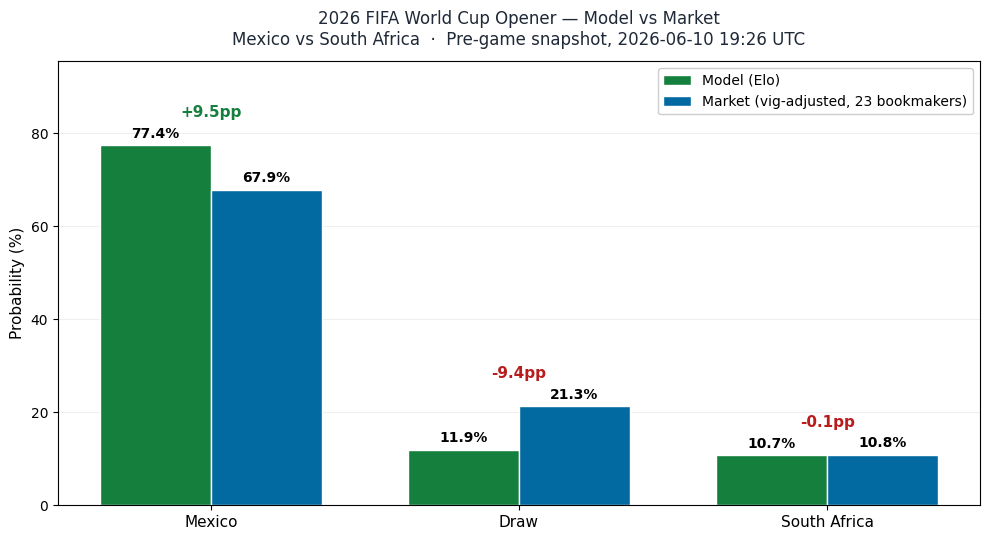

Saved opener_pregame_comparison.png


In [5]:
fig, ax = plt.subplots(figsize=(10, 5.5))

outcomes = ['Mexico', 'Draw', 'South Africa']
model_probs = [p_home_model * 100, p_draw_model * 100, p_away_model * 100]
market_probs = [implied_fair['Mexico'] * 100, implied_fair['Draw'] * 100, implied_fair['South Africa'] * 100]

x = np.arange(len(outcomes))
width = 0.36

bars_model  = ax.bar(x - width/2, model_probs,  width, label='Model (Elo)', color='#15803d', edgecolor='white', linewidth=1)
bars_market = ax.bar(x + width/2, market_probs, width, label='Market (vig-adjusted, 23 bookmakers)', color='#0369a1', edgecolor='white', linewidth=1)

# Value labels on bars
for bars in [bars_model, bars_market]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 1.0,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Edge annotations between bars
for i, (m, mk) in enumerate(zip(model_probs, market_probs)):
    edge = m - mk
    edge_str = f'{edge:+.1f}pp'
    color = '#15803d' if edge > 0 else '#b91c1c'
    ax.annotate(edge_str, xy=(i, max(m, mk) + 6),
                ha='center', fontsize=11, fontweight='bold', color=color)

ax.set_xticks(x)
ax.set_xticklabels(outcomes, fontsize=11)
ax.set_ylabel('Probability (%)', fontsize=11)
ax.set_ylim(0, max(max(model_probs), max(market_probs)) + 18)
ax.set_title(
    '2026 FIFA World Cup Opener — Model vs Market\n'
    'Mexico vs South Africa  ·  Pre-game snapshot, 2026-06-10 19:26 UTC',
    fontsize=12, pad=12, color='#1f2937'
)
ax.legend(loc='upper right', framealpha=0.95, fontsize=10)
ax.grid(axis='y', alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../data/processed/opener_pregame_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved opener_pregame_comparison.png")

## 6. Fix kickoff times / Anpfiffzeiten korrigieren

A small correction to the JSON: the local kickoff time was initially entered
with the wrong timezone. This cell rewrites the three timezone-aware kickoff
strings (local, UTC, Berlin) so the record is unambiguous.

---

Eine kleine Korrektur an der JSON-Datei: die lokale Anpfiffzeit war zunächst mit
der falschen Zeitzone eingetragen. Diese Zelle überschreibt die drei zeitzonen-bewussten
Anpfiff-Strings (lokal, UTC, Berlin), damit der Eintrag eindeutig ist.

In [3]:
import json

with open("../data/processed/opener_pregame_prediction.json", "r") as f:
    rec = json.load(f)

rec["kickoff_local"] = "2026-06-11 13:00 Mexico City (CST, UTC-6)"
rec["kickoff_utc"] = "2026-06-11 19:00 UTC"
rec["kickoff_berlin"] = "2026-06-11 21:00 Berlin (CEST, UTC+2)"

with open("../data/processed/opener_pregame_prediction.json", "w") as f:
    json.dump(rec, f, indent=2)

print("Fixed kickoff times")
print(json.dumps({k: rec[k] for k in ["kickoff_local", "kickoff_utc", "kickoff_berlin"]}, indent=2))

Fixed kickoff times
{
  "kickoff_local": "2026-06-11 13:00 Mexico City (CST, UTC-6)",
  "kickoff_utc": "2026-06-11 19:00 UTC",
  "kickoff_berlin": "2026-06-11 21:00 Berlin (CEST, UTC+2)"
}


## 7. Lock in the actual result / Das tatsächliche Ergebnis festhalten

Mexico won 2-0. Both the model and the market picked the correct winner. We
compute the Brier score for each on this single match (model: 0.0765, market:
0.1602) and write the result to the same JSON. One match is not evidence about
calibration in either direction; it is the first data point of many.

---

Mexiko gewann 2-0. Sowohl das Modell als auch der Markt wählten den richtigen
Sieger. Wir berechnen den Brier-Score für beide auf diesem einzelnen Spiel
(Modell: 0.0765, Markt: 0.1602) und schreiben das Ergebnis in dieselbe JSON-Datei.
Ein Spiel ist kein Beweis für die Kalibrierung in irgendeine Richtung; es ist
der erste Datenpunkt von vielen.

In [1]:
# Lock in the actual result (Mexico 2 - 0 South Africa)
import json

with open("../data/processed/opener_pregame_prediction.json", "r") as f:
    rec = json.load(f)

rec["actual_result"] = {
    "home_score": 2,
    "away_score": 0,
    "winner": "Mexico",
    "ht_home": 1,
    "ht_away": 0,
    "data_source": "football-data.org (automatically fetched)",
}

# Did the model and market pick the right side?
rec["evaluation"] = {
    "model_picked_correct_winner": True,
    "market_picked_correct_winner": True,
    # Brier score for THIS match (one observation; lower = better)
    # outcome vector: (1, 0, 0) for Mexico win
    "model_brier":  round(sum([
        (rec["model"]["probabilities"]["Mexico"] - 1) ** 2,
        (rec["model"]["probabilities"]["Draw"]   - 0) ** 2,
        (rec["model"]["probabilities"]["South Africa"] - 0) ** 2,
    ]), 4),
    "market_brier": round(sum([
        (rec["market"]["implied_probabilities_fair"]["Mexico"] - 1) ** 2,
        (rec["market"]["implied_probabilities_fair"]["Draw"]   - 0) ** 2,
        (rec["market"]["implied_probabilities_fair"]["South Africa"] - 0) ** 2,
    ]), 4),
}

with open("../data/processed/opener_pregame_prediction.json", "w") as f:
    json.dump(rec, f, indent=2)

print("Locked in actual result:")
print(json.dumps(rec["actual_result"], indent=2))
print("\nEvaluation:")
print(json.dumps(rec["evaluation"], indent=2))
print(f"\n>>> Model Brier: {rec['evaluation']['model_brier']}")
print(f">>> Market Brier: {rec['evaluation']['market_brier']}")
print(f">>> Winner: {'Model' if rec['evaluation']['model_brier'] < rec['evaluation']['market_brier'] else 'Market'}")

Locked in actual result:
{
  "home_score": 2,
  "away_score": 0,
  "winner": "Mexico",
  "ht_home": 1,
  "ht_away": 0,
  "data_source": "football-data.org (automatically fetched)"
}

Evaluation:
{
  "model_picked_correct_winner": true,
  "market_picked_correct_winner": true,
  "model_brier": 0.0765,
  "market_brier": 0.1602
}

>>> Model Brier: 0.0765
>>> Market Brier: 0.1602
>>> Winner: Model
